# Day 2 — Retrieval over the AI Media Dataset

*anatoolbox try-out notebook · HSLU Computational Language Technologies capstone*

This notebook tries out what was built on Day 2 of the `anatoolbox` build, on the real
[AI Media Dataset](https://www.kaggle.com/datasets/jannalipenkova/ai-media-dataset):

| New today | What it gives you in the project |
|---|---|
| `ingest_corpus` | Load the Kaggle CSV as a queryable corpus — no Elasticsearch, no vector DB |
| `retrieve_passages` with `strategy = sparse / dense / hybrid` | **Stage 3:** compare retrieval strategies by changing one argument |
| `date_from` / `date_to` | **Stage 3:** temporal grounding — retrieve evidence from a time window |
| Recordsets with lineage | Every retrieval is traceable to the corpus and settings that produced it |

**What the toolbox does, and what stays yours.** The toolbox owns the plumbing: loading,
indexing, ranking, provenance. The *methods* stay your work — how you scope your topic
track, clean the text, chunk articles, and which embedding model you train in Stage 2.
Sections 8 and 9 show where your own choices plug in.

⏱ About 3–5 minutes end to end on a CPU. Dense retrieval sections are skipped automatically
if `sentence-transformers` is not installed.

## 0 · Setup

In [1]:
# Colab: install anatoolbox first. Until the repository is public, upload or clone it and
# install from the folder, for example:
#   %pip install -q -e "/content/anatoolbox[embeddings]"
import importlib.util
import os
import platform
import sys

import anatoolbox

IN_COLAB = "google.colab" in sys.modules
HAS_EMBEDDINGS = importlib.util.find_spec("sentence_transformers") is not None

print("python     :", platform.python_version())
print("anatoolbox :", anatoolbox.__version__)
print("dense retrieval with a real model:", "available" if HAS_EMBEDDINGS else "not installed — dense sections will be skipped")

python     : 3.11.8
anatoolbox : 0.1.0
dense retrieval with a real model: available


## 1 · Get the AI Media Dataset

The notebook downloads the dataset straight from Kaggle's public API — **no Kaggle account
needed** — and caches it in `data/`. Set the environment variable `AI_MEDIA_CSV` to use a
copy you already have. If you are offline, it falls back to a tiny built-in sample so every
cell still runs.

In [2]:
import csv
import io
import urllib.request
import zipfile
from pathlib import Path

import pandas as pd

pd.set_option("display.max_colwidth", 100)
DATA_DIR = Path(os.environ.get("AI_MEDIA_DATA_DIR", "data"))
DATA_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/jannalipenkova/ai-media-dataset"

SAMPLE_ROWS = [
    ("2024-10-02", "Standards for AI agents on the web proposed", "thenewstack",
     ["A draft standard describes how autonomous agents authenticate to web services.",
      "The proposal covers capability discovery and agent-to-agent messaging."], ["AIAgents", "Standards"]),
    ("2025-02-11", "Browser agents move into enterprise workflows", "venturebeat",
     ["Agentic browsers now complete multi-step tasks on company intranets.",
      "Vendors are adding audit logs so humans can review what the agent did."], ["AIAgents", "Enterprise"]),
    ("2025-06-20", "Model Context Protocol adoption grows", "builtin",
     ["MCP servers let agents call tools and data sources through one interface.",
      "Several major model providers announced support this quarter."], ["MCP", "AIAgents"]),
    ("2024-11-14", "AI accelerator supply remains tight", "marketbeat",
     ["Demand for GPUs used in data centers continues to outpace supply."], ["GPU", "DataCenter"]),
    ("2025-04-03", "New export rules target AI chips", "techcrunch",
     ["Updated export controls restrict shipments of advanced AI chips."], ["GPU", "Policy"]),
    ("2025-01-22", "Open-weight foundation model released", "venturebeat",
     ["The model family adds a long-context variant with strong reasoning results."], ["LargeLanguageModel"]),
]


def write_sample(path):
    with path.open("w", newline="", encoding="utf-8") as fh:
        writer = csv.writer(fh)
        writer.writerow(["Unnamed: 0", "title", "date", "content", "domain", "url", "tags"])
        for i, (date, title, domain, paragraphs, tags) in enumerate(SAMPLE_ROWS):
            writer.writerow([i, title, date, str(paragraphs), domain, f"https://example.org/{i}", str(tags)])
    return path


def find_or_download_csv():
    explicit = os.environ.get("AI_MEDIA_CSV")
    if explicit and Path(explicit).exists():
        return Path(explicit), "provided via AI_MEDIA_CSV"
    cached = sorted(DATA_DIR.glob("ai_media_dataset_*.csv"))
    if cached:
        return cached[-1], "cached"
    try:
        print("Downloading the AI Media Dataset from Kaggle (~58 MB) …")
        with urllib.request.urlopen(KAGGLE_URL, timeout=180) as response:
            payload = response.read()
        with zipfile.ZipFile(io.BytesIO(payload)) as archive:
            name = next(n for n in archive.namelist() if n.endswith(".csv"))
            archive.extract(name, DATA_DIR)
        return DATA_DIR / name, "downloaded"
    except Exception as exc:  # offline, proxy, rate limit, ...
        print(f"Download failed ({exc!r}) — using the built-in sample instead.")
        return write_sample(DATA_DIR / "ai_media_sample.csv"), "built-in sample"


CSV_PATH, CSV_SOURCE = find_or_download_csv()
df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"])
print(f"{CSV_PATH.name} ({CSV_SOURCE}): {len(df):,} articles, columns {df.columns.tolist()}")
print(f"published {df['date'].min():%Y-%m-%d} → {df['date'].max():%Y-%m-%d}")

ai_media_dataset_20250911.csv (provided via AI_MEDIA_CSV): 16,527 articles, columns ['Unnamed: 0', 'title', 'date', 'content', 'domain', 'url', 'tags']
published 2024-09-11 → 2025-08-24


**Two things to notice about the raw file:**

1. `content` and `tags` are **stringified Python lists** — the text below starts with `['`.
   `ingest_corpus` turns these back into real lists on load (section 4).
2. The published Kaggle version covers **September 2024 to August 2025**. The project brief
   describes a corpus extended to August 2026; until that version is published, temporal
   analyses end in August 2025, and August 2025 itself is a partial month.

In [3]:
raw = df.iloc[0]
print("content:", repr(raw["content"][:160]), "…")
print("tags   :", repr(raw["tags"]))

content: "['The Digit humanoid could work in distribution, retail and e-commerce, manufacturing, and third-party logistics. | Source: Agility Robotics', 'Agility Robotics" …
tags   : "['Robotics', 'Video', 'BostonDynamics']"


## 2 · Pick your topic track

The keyword patterns below are a deliberately crude way to scope a track — just enough to
drive this notebook. Defining the track boundary properly (entity lists, a schema) is part of
your Stage 1 work. Change `TRACK` to follow your group's choice.

In [4]:
TRACKS = {
    "Hardware & Infrastructure": r"\bgpus?\b|accelerator|nvidia|data cent(?:er|re)|semiconductor|\btsmc\b|\bchips?\b",
    "Foundation Models": r"foundation model|large language model|\bllms?\b|gpt-?\d|\bllama\b|gemini|claude|mistral|\bqwen\b",
    "Agentic Web": r"ai agents?|agentic|\bmcp\b|model context protocol|agent2agent|\ba2a\b|browser agent|computer use",
}
TRACK = "Agentic Web"   # ← "Hardware & Infrastructure" | "Foundation Models" | "Agentic Web"

haystack = (df["title"] + " " + df["content"] + " " + df["tags"]).str.lower()
df["in_track"] = haystack.str.contains(TRACKS[TRACK], regex=True)
df["month"] = df["date"].dt.to_period("M")

monthly = (
    df.groupby("month")
    .agg(track=("in_track", "sum"), corpus=("in_track", "size"))
    .assign(share=lambda t: t["track"] / t["corpus"])
)
print(f"{TRACK}: {int(df['in_track'].sum()):,} of {len(df):,} articles ({df['in_track'].mean():.1%})")

Agentic Web: 2,572 of 16,527 articles (15.6%)


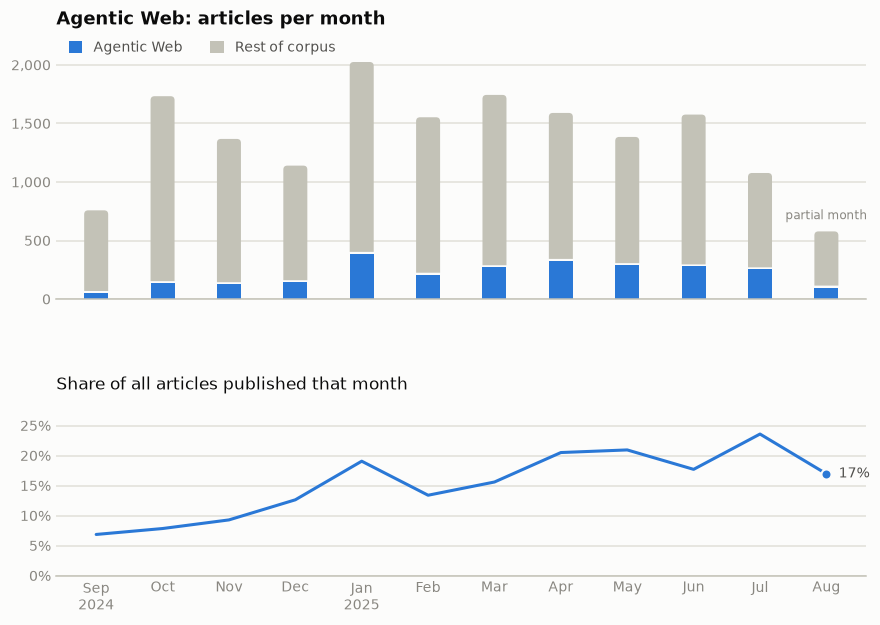

,Agentic Web,all articles,share %
month,,,
2024-09,52,758,6.9
2024-10,136,1733,7.8
2024-11,127,1368,9.3
2024-12,144,1140,12.6
2025-01,386,2025,19.1
2025-02,208,1553,13.4
2025-03,272,1744,15.6
2025-04,326,1590,20.5
2025-05,290,1385,20.9


In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, PathPatch, Rectangle
from matplotlib.path import Path as MplPath
from matplotlib.ticker import FuncFormatter, PercentFormatter

CHART_THEME = "light"   # ← set to "dark" if you use a dark notebook theme
TOKENS = {
    "light": dict(surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e", muted="#898781",
                  grid="#e1e0d9", baseline="#c3c2b7", series="#2a78d6", context="#c3c2b7"),
    "dark":  dict(surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7", muted="#898781",
                  grid="#2c2c2a", baseline="#383835", series="#3987e5", context="#898781"),
}


def _px_scale(ax):
    # data units per screen pixel, for pixel-exact bar widths, caps and gaps
    bbox = ax.get_window_extent()
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    return (x1 - x0) / bbox.width, (y1 - y0) / bbox.height


def _column(ax, x, bottom, height, color, *, rounded, xpp, ypp):
    width = 24 * xpp                    # bars never wider than 24px
    left, right, top = x - width / 2, x + width / 2, bottom + height
    rx, ry = 4 * xpp, 4 * ypp           # 4px rounded data-end, square at the baseline
    if height <= 0:
        return
    if not rounded or height < 2 * ry:
        ax.add_patch(Rectangle((left, bottom), width, height, facecolor=color, edgecolor="none"))
        return
    # one closed path, so there is no seam where two overlapping shapes meet
    vertices = [(left, bottom), (left, top - ry), (left, top), (left + rx, top), (right - rx, top),
                (right, top), (right, top - ry), (right, bottom), (left, bottom)]
    codes = [MplPath.MOVETO, MplPath.LINETO, MplPath.CURVE3, MplPath.CURVE3, MplPath.LINETO,
             MplPath.CURVE3, MplPath.CURVE3, MplPath.LINETO, MplPath.CLOSEPOLY]
    ax.add_patch(PathPatch(MplPath(vertices, codes), facecolor=color, edgecolor="none"))


def _style(ax, t):
    ax.set_facecolor(t["surface"])
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(t["baseline"])
    ax.spines["bottom"].set_linewidth(1)
    ax.grid(axis="y", color=t["grid"], linewidth=1, linestyle="-")
    ax.set_axisbelow(True)
    ax.tick_params(length=0, colors=t["muted"], labelsize=9)


def plot_track_volume(monthly, track, theme="light", partial_last_month=False):
    t = TOKENS[theme]
    n = len(monthly)
    xs = list(range(n))
    labels = [f"{p:%b}\n{p:%Y}" if (p.month in (1, 9) or i == 0) else f"{p:%b}"
              for i, p in enumerate(monthly.index.to_timestamp())]

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.5, 6.4), dpi=110, sharex=True,
                                      gridspec_kw={"height_ratios": [3, 2], "hspace": 0.45})
    fig.patch.set_facecolor(t["surface"])
    for ax in (top, bottom):
        _style(ax, t)

    # top: stacked columns — the track, a 2px surface gap, then the rest of the corpus
    top.set_xlim(-0.6, n - 0.4)
    top.set_ylim(0, monthly["corpus"].max() * 1.12)
    fig.canvas.draw()
    xpp, ypp = _px_scale(top)
    gap = 2 * ypp
    for x, (track_n, total) in zip(xs, monthly[["track", "corpus"]].itertuples(index=False)):
        _column(top, x, 0, track_n, t["series"], rounded=False, xpp=xpp, ypp=ypp)
        _column(top, x, track_n + gap, total - track_n - gap, t["context"], rounded=True, xpp=xpp, ypp=ypp)
    top.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    top.set_title(f"{track}: articles per month", loc="left", color=t["ink"], fontsize=12, fontweight="bold")
    top.legend(handles=[Patch(facecolor=t["series"], label=track),
                        Patch(facecolor=t["context"], label="Rest of corpus")],
               loc="upper left", frameon=False, fontsize=9, labelcolor=t["ink2"], ncol=2,
               bbox_to_anchor=(0, 1.02), handlelength=1.0, handleheight=1.0)
    if partial_last_month:  # the data ends before the last month does
        top.annotate("partial month", (xs[-1], monthly["corpus"].iloc[-1]), xytext=(0, 6),
                     textcoords="offset points", ha="center", va="bottom", fontsize=8, color=t["muted"])

    # bottom: the track's share of each month — the trend that raw counts hide
    share = monthly["share"].to_numpy()
    bottom.plot(xs, share, color=t["series"], linewidth=2, solid_capstyle="round", solid_joinstyle="round")
    bottom.scatter([xs[-1]], [share[-1]], s=(10 * 72 / fig.dpi) ** 2, color=t["series"],
                   edgecolors=t["surface"], linewidths=2 * 72 / fig.dpi, zorder=3)
    bottom.annotate(f"{share[-1]:.0%}", (xs[-1], share[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", fontsize=9, color=t["ink2"])
    bottom.set_ylim(0, share.max() * 1.25)
    bottom.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    bottom.set_title("Share of all articles published that month", loc="left", color=t["ink"], fontsize=11)
    bottom.set_xticks(xs, labels)
    plt.show()


last_day = df["date"].max()
partial = last_day < last_day.to_period("M").to_timestamp(how="end").normalize()
plot_track_volume(monthly, TRACK, theme=CHART_THEME, partial_last_month=partial)

# the same numbers as a table — the chart's accessible twin
monthly.assign(share=lambda t: (t["share"] * 100).round(1)).rename(
    columns={"track": TRACK, "corpus": "all articles", "share": "share %"})

## 3 · The grammar: every tool names its task type

Day 1 foundations in one cell. anatoolbox ships **contracts, not a tool catalog**: tools are
named `<prefix><object>`, and the prefix places them in a research stage. Importing the
package registers nothing; `register_reference_tools()` adds the two tools this notebook uses.

In [6]:
from anatoolbox.stages import STAGE_ORDER, prefixes_for_stage

anatoolbox.register_reference_tools()
for stage in STAGE_ORDER:
    print(f"{stage:8} {' '.join(prefixes_for_stage(stage))}")
print()
for name in anatoolbox.registered_names():
    print(f"{name:18} → stage '{anatoolbox.stage_for_tool_name(name)}'")

prepare  plan_
gather   ingest_ monitor_ retrieve_
extract  deduplicate_ detect_ extract_ normalize_ parse_ resolve_
analyze  aggregate_ calculate_ classify_ compare_ identify_ model_ score_ trend_
enrich   assess_ benchmark_ calibrate_ enrich_ explain_ interpret_ recommend_ synthesize_ validate_ weight_
present  chart_ export_ report_ summarize_ tabulate_ visualize_

ingest_corpus      → stage 'gather'
retrieve_passages  → stage 'gather'


## 4 · Ingest the corpus

A `ToolContext` carries the session's **recordset memory**. Tools write what they produce
there and read what earlier stages produced — by *handle*, not by pasting data around.

In [7]:
from anatoolbox import ToolContext
from anatoolbox.corpus import get_corpus
from anatoolbox.memory.facade import Memory
from anatoolbox.memory.policy import RetainAllMemoryPolicy
from anatoolbox.memory.store import InMemoryRecordsetStore

memory = Memory(InMemoryRecordsetStore(), RetainAllMemoryPolicy(), project="hslu-ai-media", session_id="day2")
ctx = ToolContext(project="hslu-ai-media", session_id="day2", recordsets=memory)
ingest, retrieve = anatoolbox.resolve_tools(["ingest_corpus", "retrieve_passages"])

info = ingest.run({"path": str(CSV_PATH), "name": "ai_media", "text_field": "content", "id_field": "Unnamed: 0"},
                  context=ctx)
FULL = info["handle"]
print(f"{info['records']:,} records → handle {FULL!r}")

stored = memory.get(FULL)
print("stored by reference:", stored.ref["mode"], "|", len(stored.ref["ids"]), "ids |",
      "document bodies in memory:", "records" in stored.ref)

corpus = get_corpus("ai_media")
first = corpus.records[0]
print("\ntags after ingest :", first["tags"])
print("text after ingest :", repr(corpus.text_of(first)[:160]), "…")

16,527 records → handle 'corpus_1'
stored by reference: reference | 16527 ids | document bodies in memory: False

tags after ingest : ['Robotics', 'Video', 'BostonDynamics']
text after ingest : 'The Digit humanoid could work in distribution, retail and e-commerce, manufacturing, and third-party logistics. | Source: Agility Robotics\n\nAgility Robotics Inc' …


## 5 · Sparse retrieval (BM25) on your track's questions

The **first** query builds the BM25 index for all ~16k articles, which takes a few seconds.
Every later query reuses it.

In [8]:
import time

QUESTIONS = {
    "Agentic Web": [
        "standards for AI agents interacting with web services",
        "Model Context Protocol adoption by model providers",
        "security risks of autonomous browser agents",
    ],
    "Hardware & Infrastructure": [
        "export restrictions on AI chips to China",
        "data center power demand for AI training",
        "custom AI accelerators built by cloud providers",
    ],
    "Foundation Models": [
        "open-weight foundation model releases",
        "long context windows in large language models",
        "reasoning models and test-time compute",
    ],
}


def table(result, n=5, width=90):
    rows = result["passages"][:n]
    return pd.DataFrame({
        "rank": [p["rank"] for p in rows],
        "score": [round(p["score"], 3) for p in rows],
        "date": [p.get("date") for p in rows],
        "title": [str(p.get("title"))[:70] for p in rows],
        "snippet": [p["snippet"][:width].replace("\n", " ") + " …" for p in rows],
    })


for question in QUESTIONS[TRACK]:
    started = time.perf_counter()
    out = retrieve.run({"query": question, "strategy": "sparse", "size": 5, "input": FULL}, context=ctx)
    print(f"\n{question!r}  ({time.perf_counter() - started:.2f} s, handle {out['handle']})")
    display(table(out))


'standards for AI agents interacting with web services'  (10.98 s, handle passages_1)


,rank,score,date,title,snippet
0,1,14.913,2025-05-15,"Comparing MCP, A2A, and AGNTCY in the AI Agent Ecosystem","A few weeks ago, I wrote an article in the Cisco Security Community about “ Model Context …"
1,2,14.386,2025-06-18,Designing Collaborative Multi-Agent Systems with the A2A Protocol – O’,"With the O’ Reilly learning platform, you get the resources and guidance to keep your skil …"
2,3,14.233,2024-10-21,Gartner: 2025 will see the rise of AI agents ( and other top trends),Join our daily and weekly newsletters for the latest updates and exclusive content on indu …
3,4,14.219,2025-08-11,Study warns of security risks as ‘ OS agents’ gain control of computer,Want smarter insights in your inbox? Sign up for our weekly newsletters to get only what m …
4,5,13.310,2025-04-14,Marketing To AI Agents Is The Future – Research Shows Why,Drive more conversions for your clients. Get the 2025 Outlook Report + 6 Ways to Boost AI' …



'Model Context Protocol adoption by model providers'  (0.07 s, handle passages_2)


,rank,score,date,title,snippet
0,1,17.655,2025-06-18,Designing Collaborative Multi-Agent Systems with the A2A Protocol – O’,"With the O’ Reilly learning platform, you get the resources and guidance to keep your skil …"
1,2,17.001,2025-07-31,Protocols and Power – O’ Reilly,Get expert-led live training on exactly what you want to learn. With the O’ Reilly learni …
2,3,16.905,2025-05-10,MCP and the innovation paradox: Why open standards will save AI from i,Join our daily and weekly newsletters for the latest updates and exclusive content on indu …
3,4,16.854,2025-06-01,"Model Context Protocol: A promising AI integration layer, but not a st",Join the event trusted by enterprise leaders for nearly two decades. VB Transform brings t …
4,5,16.478,2025-05-15,AI Agents: Protocols Driving Next-Gen Enterprise Intelligence,We’ re so glad you’ re here. You can expect all the best TNS content to arrive Monday thro …



'security risks of autonomous browser agents'  (0.07 s, handle passages_3)


,rank,score,date,title,snippet
0,1,16.120,2025-05-23,"OpenAI updates Operator to o3, making its $ 200 monthly ChatGPT Pro su",Join our daily and weekly newsletters for the latest updates and exclusive content on indu …
1,2,15.708,2025-07-02,Bright Data beat Elon Musk and Meta in court — now its $ 100M AI platf,Want smarter insights in your inbox? Sign up for our weekly newsletters to get only what m …
2,3,15.465,2025-02-22,The rise of browser-use agents: Why Convergence’ s Proxy is beating Op,Join our daily and weekly newsletters for the latest updates and exclusive content on indu …
3,4,14.718,2025-04-16,The Future of AI is Local,"While AI tools frequently provide rapid and useful responses to our queries, we’ ve all se …"
4,5,14.414,2025-02-14,Computer-using agent ( CUA) models,"The tool offers real-time insights into regulatory changes relevant to a business, mitigat …"


**Look at the snippets.** Many articles *open* with site boilerplate rather than content —
newsletter sign-ups, consent notices, even scraped page-load errors. BM25 is fairly robust to it
because it scores the whole article, but anything that reads the start of the text — an
embedding model, a snippet shown to an LLM — is not.

A hand-written phrase list badly undercounts this. The cell below measures it from the data
instead: site boilerplate *repeats* across a site's articles; real opening paragraphs do not.
Cleaning it is Stage 1 work — and it directly affects Stage 3.

In [9]:
def first_paragraph(record):
    content = record["content"]
    return (content[0] if isinstance(content, list) and content else str(content)).strip()


MIN_REPEATS = 5   # an opening shared by 5+ articles is a site template, not content

openings = pd.DataFrame({
    "opening": [first_paragraph(r)[:80] for r in corpus.records],
    "domain": [r["domain"] for r in corpus.records],
})
openings["repeats"] = openings["opening"].map(openings["opening"].value_counts())
boilerplate = openings["repeats"] >= MIN_REPEATS
print(f"{boilerplate.sum():,} of {len(openings):,} articles ({boilerplate.mean():.1%}) open with a paragraph "
      f"shared by {MIN_REPEATS}+ articles")

(openings[boilerplate]
 .groupby("opening")
 .agg(articles=("domain", "size"), domain=("domain", lambda d: d.mode().iat[0]))
 .sort_values("articles", ascending=False)
 .head(10))

3,866 of 16,527 articles (23.4%) open with a paragraph shared by 5+ articles


,articles,domain
opening,,
We’ re so glad you’ re here. You can expect all the best TNS content to arrive M,496,thenewstack
"The world’ s leading publication for data science, AI, and ML professionals.",493,towardsdatascience
Join our daily and weekly newsletters for the latest updates and exclusive conte,370,venturebeat
"Email address: By clicking submit, you agree to share your email address with TF",246,techfundingnews
The tool offers real-time insights into regulatory changes relevant to a busines,230,zbrain
This issue is preventing our website from loading properly. Please review the fo,229,foreignpolicy
In this article,113,cnbc
"By clicking submit, you agree to share your email address with the site owner an",77,techfundingnews
"Let CIO Dive's free newsletter keep you informed, straight from your inbox.",77,ciodive


## 6 · Temporal grounding: retrieve from a time window

Temporal questions ("what changed in 2025?") need evidence from the right period.
`date_from` / `date_to` filter *while walking the ranking*, so each window still returns a full
set of results, and the window is recorded in the result's provenance.

In [10]:
question = QUESTIONS[TRACK][0]
windows = {
    "H2 2024": ("2024-07-01", "2024-12-31"),
    "H1 2025": ("2025-01-01", "2025-06-30"),
    "Jul–Aug 2025": ("2025-07-01", "2025-08-31"),
}
for label, (start, end) in windows.items():
    out = retrieve.run({"query": question, "strategy": "sparse", "size": 3, "input": FULL,
                        "date_from": start, "date_to": end}, context=ctx)
    print(f"\n{label}  →  provenance args: {memory.get(out['handle']).args}")
    display(table(out, n=3))


H2 2024  →  provenance args: {'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus': 'ai_media', 'date_from': '2024-07-01', 'date_to': '2024-12-31'}


,rank,score,date,title,snippet
0,1,14.233,2024-10-21,Gartner: 2025 will see the rise of AI agents ( and other top trends),Join our daily and weekly newsletters for the latest updates and exclusive content on indu …
1,2,12.813,2024-10-05,AI Agents: The Intersection of Tool Calling and Reasoning in Generativ,"The world’ s leading publication for data science, AI, and ML professionals. Today, new l …"
2,3,12.341,2024-11-18,The 10 Coolest GenAI Products And AI Tools Of 2024,"Here are the 10 coolest GenAI products and AI Tools of 2024 that you need to know about, i …"



H1 2025  →  provenance args: {'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus': 'ai_media', 'date_from': '2025-01-01', 'date_to': '2025-06-30'}


,rank,score,date,title,snippet
0,1,14.913,2025-05-15,"Comparing MCP, A2A, and AGNTCY in the AI Agent Ecosystem","A few weeks ago, I wrote an article in the Cisco Security Community about “ Model Context …"
1,2,14.386,2025-06-18,Designing Collaborative Multi-Agent Systems with the A2A Protocol – O’,"With the O’ Reilly learning platform, you get the resources and guidance to keep your skil …"
2,3,13.310,2025-04-14,Marketing To AI Agents Is The Future – Research Shows Why,Drive more conversions for your clients. Get the 2025 Outlook Report + 6 Ways to Boost AI' …



Jul–Aug 2025  →  provenance args: {'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus': 'ai_media', 'date_from': '2025-07-01', 'date_to': '2025-08-31'}


,rank,score,date,title,snippet
0,1,14.219,2025-08-11,Study warns of security risks as ‘ OS agents’ gain control of computer,Want smarter insights in your inbox? Sign up for our weekly newsletters to get only what m …
1,2,12.771,2025-07-11,Beyond the Hype: Why Agentic AI is Closer Than you Think,"“ When I hear ‘ 2025 is the year of agents,’ I get nervous… this is the decade of agents. …"
2,3,12.721,2025-07-03,"Chatbots are on the rise, but customers still trust human agents more","Customers contact companies regularly to purchase products and services, inquire about ord …"


## 7 · Dense and hybrid retrieval on your track

Embedding all 16k articles on a CPU takes ~5 minutes, so this section works on a sample of
your track. It goes through `ingest_corpus` again, which shows **binding**: `retrieve_passages`
without an `input` handle uses the *newest* corpus — the track sample.

`hybrid` fuses the sparse and dense rankings by rank position (reciprocal rank fusion), so
BM25 scores and cosine similarities never have to be put on one scale.

In [11]:
from anatoolbox.corpus import configure_embedder, sentence_transformer_embedder

N_TRACK_ARTICLES = 400
track_sample = df[df["in_track"]].sample(n=min(N_TRACK_ARTICLES, int(df["in_track"].sum())), random_state=0)
track_csv = DATA_DIR / "track_sample.csv"
track_sample.drop(columns=["in_track", "month"]).assign(date=lambda t: t["date"].dt.strftime("%Y-%m-%d")).to_csv(track_csv, index=False)

TRACK_CORPUS = ingest.run({"path": str(track_csv), "name": "track_articles", "text_field": "content",
                           "id_field": "Unnamed: 0"}, context=ctx)["handle"]
print(f"track sample: {len(track_sample)} articles → {TRACK_CORPUS!r}")

if HAS_EMBEDDINGS:
    configure_embedder(sentence_transformer_embedder("all-MiniLM-L6-v2"))
    question = QUESTIONS[TRACK][0]
    results = {}
    for strategy in ("sparse", "dense", "hybrid"):
        started = time.perf_counter()
        results[strategy] = retrieve.run({"query": question, "strategy": strategy, "size": 10}, context=ctx)
        print(f"{strategy:6}: {time.perf_counter() - started:5.1f} s, bound to {results[strategy]['input_handle']}")
    print(f"\n{question!r}")
    display(pd.DataFrame({s: [str(p.get("title"))[:48] for p in r["passages"][:5]] for s, r in results.items()},
                         index=range(1, 6)))
else:
    print("sentence-transformers is not installed — skipping dense and hybrid.")

track sample: 400 articles → 'corpus_2'


sparse:   0.5 s, bound to corpus_2


dense :  15.3 s, bound to corpus_2
hybrid:   0.0 s, bound to corpus_2

'standards for AI agents interacting with web services'


,sparse,dense,hybrid
1,Designing Collaborative Multi-Agent Systems with,AI Agents in Networking Industry,Microsoft announces over 50 AI tools to build th
2,Study warns of security risks as ‘ OS agents’ ga,Microsoft announces over 50 AI tools to build th,Study warns of security risks as ‘ OS agents’ ga
3,Microsoft announces over 50 AI tools to build th,3 Things We Need To Fix Before AI Agents Go Main,Designing Collaborative Multi-Agent Systems with
4,Firebase Studio lets you build full-stack AI app,Dawn of the Agent: New Claude AI can take over y,Salesforce just unveiled AI ‘ digital teammates’
5,Google Marketing Live 2025: Driving Growth with,The Download: How fertility tech is changing fam,Can Agentless AI Replace Traditional AI Agents?


How much do the strategies agree? Overlap of their top-10 results (Jaccard: 1.0 = identical sets):

In [12]:
if HAS_EMBEDDINGS:
    top = {s: {p["id"] for p in r["passages"]} for s, r in results.items()}
    display(pd.DataFrame({a: {b: round(len(top[a] & top[b]) / max(1, len(top[a] | top[b])), 2) for b in top} for a in top}))

,sparse,dense,hybrid
sparse,1.00,0.05,0.33
dense,0.05,1.00,0.18
hybrid,0.33,0.18,1.00


## 8 · Why dense retrieval is handicapped here — and what chunking changes

`all-MiniLM-L6-v2` reads at most **256 tokens**. The cell below measures how long the
articles actually are. If most exceed the window, "dense retrieval over articles" really means
*embedding the first ~256 tokens* — often the boilerplate from section 5 — while BM25 sees
everything. That makes the section 7 comparison unfair to dense retrieval.

The fix is chunking: split articles into passages and retrieve those. **The chunker below is
deliberately simple and meant to be replaced** — chunking strategy is one of the Stage 3
enhancements you can choose to study.

In [13]:
if HAS_EMBEDDINGS:
    from sentence_transformers import SentenceTransformer

    tokenizer = SentenceTransformer("all-MiniLM-L6-v2").tokenizer
    track_corpus = get_corpus("track_articles")
    lengths = pd.Series([len(tokenizer(text, add_special_tokens=False)["input_ids"]) for text in track_corpus.texts()])
    print(f"article length in tokens: median {lengths.median():.0f}, 90th percentile {lengths.quantile(0.9):.0f}")
    print(f"articles longer than the 256-token window: {(lengths > 256).mean():.0%}")

article length in tokens: median 1554, 90th percentile 3248
articles longer than the 256-token window: 100%


In [14]:
WORDS_PER_PASSAGE = 150


def chunk_paragraphs(paragraphs, max_words=WORDS_PER_PASSAGE):
    # Greedy: pack whole paragraphs into ~max_words windows. Replace me with your own chunker.
    passages, current, count = [], [], 0
    for paragraph in paragraphs:
        words = len(paragraph.split())
        if current and count + words > max_words:
            passages.append("\n\n".join(current))
            current, count = [], 0
        current.append(paragraph)
        count += words
    if current:
        passages.append("\n\n".join(current))
    return passages


if HAS_EMBEDDINGS:
    rows = []
    for record in get_corpus("track_articles").records:
        for k, passage in enumerate(chunk_paragraphs(record["content"])):
            rows.append({"id": f"{record['Unnamed: 0']}#{k}", "article_id": record["Unnamed: 0"],
                         "title": record["title"], "date": record["date"], "domain": record["domain"],
                         "url": record["url"], "text": passage})
    passages_csv = DATA_DIR / "track_passages.csv"
    pd.DataFrame(rows).to_csv(passages_csv, index=False)
    PASSAGE_CORPUS = ingest.run({"path": str(passages_csv), "name": "track_passages", "text_field": "text"},
                                context=ctx)["handle"]
    print(f"{len(track_sample)} articles → {len(rows):,} passages → {PASSAGE_CORPUS!r}")

    question = QUESTIONS[TRACK][0]
    started = time.perf_counter()
    by_passage = retrieve.run({"query": question, "strategy": "dense", "size": 5}, context=ctx)
    print(f"dense over passages: {time.perf_counter() - started:.1f} s (includes embedding every passage once)")
    by_article = retrieve.run({"query": question, "strategy": "dense", "size": 5, "input": TRACK_CORPUS}, context=ctx)

400 articles → 5,175 passages → 'corpus_3'


dense over passages: 66.6 s (includes embedding every passage once)


Same question, same model. What evidence would each version hand to an LLM? Compare the
**top-ranked text** — the article-level hit can only show the article's opening; the
passage-level hit is the part of the article that matched.

In [15]:
if HAS_EMBEDDINGS:
    for label, result in (("dense over whole articles", by_article), ("dense over passages", by_passage)):
        best = result["passages"][0]
        print(f"— {label}  [{best.get('date')}] {str(best.get('title'))[:80]}")
        print("  ", best["snippet"][:400].replace("\n", " "), "…\n")

— dense over whole articles  [2024-11-27] AI Agents in Networking Industry
   The world’ s leading publication for data science, AI, and ML professionals.  AI agents have been all the rage in 2024 and rightfully so. Unlike traditional AI models or interactions with Large Language Models ( LLMs) that provide responses based on static training data, AI agents are dynamic entities that can perceive, reason ( due to prompting techniques), and act autonomously within their opera …

— dense over passages  [2025-05-19] Microsoft announces over 50 AI tools to build the ‘ agentic web’ at Build 2025
   “ We’ ve entered the era of AI agents, ” said Frank Shaw, Microsoft’ s Chief Communications Officer, in a blog post coinciding with the Build announcements. “ Thanks to groundbreaking advancements in reasoning and memory, AI models are now more capable and efficient, and we’ re seeing how AI systems can help us all solve problems in new ways. ”  The concept of the “ agentic web ” moves far beyond 

There are no relevance labels yet, so this is a qualitative look rather than a measurement.
**Day 4** adds scoring (faithfulness, relevance, context and temporal grounding) so comparisons
like this one become numbers.

## 9 · Bring your own embedding model (Stage 2 → Stage 3)

Any function from a list of texts to vectors is an embedder. Plug in the model you fine-tuned in
Stage 2 with `configure_embedder` — cached embeddings from the previous model are discarded
automatically, so nothing is silently ranked with the old vectors.

In [16]:
# from sentence_transformers import SentenceTransformer
# my_model = SentenceTransformer("path/to/your/stage2-model")
#
# def my_embedder(texts):
#     return my_model.encode(texts, normalize_embeddings=True)
#
# configure_embedder(my_embedder)
# retrieve.run({"query": "...", "strategy": "dense", "input": PASSAGE_CORPUS}, context=ctx)

## 10 · Lineage: what every result rests on

Everything above was recorded. Each retrieval knows which corpus it came from and with which
settings — the audit trail you need in Stage 3 when you report *why* an answer used the evidence
it did. Bodies are never stored in memory; they are re-read from the corpus when needed.

In [17]:
lineage = pd.DataFrame([
    {"handle": r.handle, "type": r.object_type, "produced_by": r.produced_by, "count": r.count,
     "derived_from": ", ".join(r.derived_from),
     "settings": {k: v for k, v in r.args.items() if k in ("query", "strategy", "date_from", "date_to", "corpus")}}
    for r in sorted(memory.list(), key=lambda r: r.created_at)
])
display(lineage)

latest = sorted((r for r in memory.list() if r.object_type == "passages"), key=lambda r: r.created_at)[-1]
print(f"re-reading {latest.handle} from its corpus, titles only:")
for row in memory.records(latest, source_includes=["title", "date"])[:3]:
    print("  ", row)

,handle,type,produced_by,count,derived_from,settings
0,corpus_1,corpus,ingest_corpus,16527,,{'corpus': 'ai_media'}
1,passages_1,passages,retrieve_passages,5,corpus_1,"{'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus..."
2,passages_2,passages,retrieve_passages,5,corpus_1,"{'query': 'Model Context Protocol adoption by model providers', 'strategy': 'sparse', 'corpus': ..."
3,passages_3,passages,retrieve_passages,5,corpus_1,"{'query': 'security risks of autonomous browser agents', 'strategy': 'sparse', 'corpus': 'ai_med..."
4,passages_4,passages,retrieve_passages,3,corpus_1,"{'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus..."
5,passages_5,passages,retrieve_passages,3,corpus_1,"{'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus..."
6,passages_6,passages,retrieve_passages,3,corpus_1,"{'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus..."
7,corpus_2,corpus,ingest_corpus,400,,{'corpus': 'track_articles'}
8,passages_7,passages,retrieve_passages,10,corpus_2,"{'query': 'standards for AI agents interacting with web services', 'strategy': 'sparse', 'corpus..."
9,passages_8,passages,retrieve_passages,10,corpus_2,"{'query': 'standards for AI agents interacting with web services', 'strategy': 'dense', 'corpus'..."


re-reading passages_11 from its corpus, titles only:
   {'Unnamed: 0': '106131', 'title': 'AI Agents in Networking Industry', 'date': '2024-11-27'}
   {'Unnamed: 0': '107499', 'title': 'Microsoft announces over 50 AI tools to build the ‘ agentic web’ at Build 2025', 'date': '2025-05-19'}
   {'Unnamed: 0': '90883', 'title': '3 Things We Need To Fix Before AI Agents Go Mainstream', 'date': '2025-02-21'}


## What to take away

- **Retrieval strategy is one argument.** Sparse, dense and hybrid run through the same tool,
  so a Stage 3 comparison changes `strategy`, not your pipeline.
- **Temporal questions need windows.** `date_from` / `date_to` keep evidence in the period the
  question asks about, and the window is recorded with the result.
- **Your preprocessing decides what dense retrieval sees.** In the published file roughly a
  quarter of articles open with repeated site boilerplate (section 5), and track articles run far
  past the 256-token window (section 8). Chunking and cleaning are not optional polish — they are
  where Stage 1 and Stage 3 meet. Watch for spacing artifacts in the source text too ("O’ Reilly").
- **Dataset scope.** The published Kaggle version ends in August 2025 (a partial month).

**Next — Day 3:** a model-agnostic LLM connection (any OpenAI-compatible endpoint, including
models you host yourself) and `synthesize_answer`, which writes answers over these passages with
inline citations back to the source articles.